In this script, we will compute and compare the features sampled from within vs. between cells. 

Related figures in Figure 2, Extended Data Figure 3.

In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'C:/GBM39/invirto_030125/112325__df-global_transcription-rgs-antibody_H__invitro_030125.csv',
                index_col = 0)

In [3]:
df_ecDNA = df[df['pool'] == 'circular']
df_ecDNA.shape

(34349, 29)

In [4]:
df_ecDNA = df_ecDNA.rename(columns = {'iA2_ab_norm_robust_H': 'PolII_brightness_z', 
                           'iA4_ab_norm_robust_H': 'SC35_brightness_z',
                          'iA5_ab_norm_robust_H': 'H3K27Ac_brightness_z',
                          'iA7_ab_norm_robust_H': 'Lamina_brightness_z',
                          'iA8_ab_norm_robust_H': 'NUP98_brightness_z'})

In [5]:
df_ecDNA

,cell_id,pool,trace_id,global_row,EGFR,EGFR-AS1,LANCL2,FKBP9P1,SEPTIN14,ZNF713,...,centroid,dist_to_com,dist_to_lamina,inside_nucleus,rgs,PolII_brightness_z,SC35_brightness_z,H3K27Ac_brightness_z,Lamina_brightness_z,NUP98_brightness_z
2,2000004,circular,0,0,1,1,1,1,0,1,...,"(2.167707350563869, 202.95043690322936, 40.099...",2.623592,5.747583,True,0.440679,5.252876,5.323480,5.610506,4.182802,4.041000
3,2000004,circular,1,1,1,1,1,1,0,1,...,"(4.780071618112078, 200.50696401424958, 43.315...",3.999200,2.435007,True,0.581685,5.514310,3.112691,4.526712,6.174078,6.362746
4,2000004,circular,2,2,1,1,1,1,0,1,...,"(4.787270550179271, 201.43230979844688, 40.511...",1.430466,5.075092,True,0.630323,5.587959,5.888163,6.024974,4.261381,4.098743
5,2000004,circular,3,3,0,0,1,0,0,0,...,"(4.614149519801138, 203.1237163707018, 43.2726...",3.272758,2.599266,True,0.365606,4.538308,3.674382,5.127682,4.837413,5.016312
6,2000004,circular,4,4,1,0,1,1,0,1,...,"(1.9761494305116902, 206.14940458586742, 42.47...",5.025992,3.914176,True,0.472574,4.883151,3.751745,4.247388,4.481245,3.886731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36813,5000033,circular,96,35964,0,1,1,1,1,1,...,"(2.434881321387954, 168.26758710780823, 269.29...",8.522946,3.762808,True,0.652002,4.075819,3.387878,3.268231,3.568626,2.846161
36814,5000033,circular,97,35965,0,0,1,0,1,1,...,"(2.202038845649133, 153.91800797714117, 275.10...",8.135643,5.554161,True,1.272979,3.036051,1.899657,3.578642,3.104820,2.992271
36815,5000033,circular,98,35966,0,1,1,0,0,1,...,"(2.0804746517768273, 153.98229632133598, 275.0...",8.065166,5.695150,True,1.265202,3.164325,1.800523,3.502400,3.107703,2.966909
36816,5000033,circular,99,35967,0,1,1,0,0,1,...,"(2.722946622294764, 165.5395771801758, 274.883...",7.269698,1.244491,True,0.471146,3.190809,1.449830,1.309748,3.208461,2.772899


In [6]:
FEATURES = [
    "total_genes_transcribed",
    "rgs",
    "PolII_brightness_z",
    "SC35_brightness_z",
    "H3K27Ac_brightness_z",
    'Lamina_brightness_z',
    'NUP98_brightness_z'
]

## z score each column

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler



def make_trace_vectors_global_z(dfe: pd.DataFrame, gene_mode="raw", robust=False):
    """
    gene_mode: "raw" (0..9) or "frac9" (0..1). Either way we z-score afterwards.
    robust: if True, use median/MAD instead of mean/std.
    """
    df = dfe.copy()
    for c in FEATURES:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if gene_mode == "frac9":
        df["total_genes_transcribed"] = df["total_genes_transcribed"] / 9.0
    elif gene_mode != "raw":
        raise ValueError("gene_mode must be 'raw' or 'frac9'")

    # drop rows with missing features
    X = df[FEATURES].to_numpy(float)
    ok = np.isfinite(X).all(axis=1)
    df = df.loc[ok].reset_index(drop=True)
    X = X[ok]

    if robust:
        med = np.median(X, axis=0)
        mad = np.median(np.abs(X - med), axis=0)
        scale = 1.4826 * mad
        scale = np.where(scale == 0, 1.0, scale)
        Xz = (X - med) / scale
    else:
        Xz = StandardScaler().fit_transform(X)

    return df, Xz

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def zscore_feature_columns(df, feature_columns):
    df_ = df.copy()

    for col in feature_columns:
        if col == 'total_genes_transcribed':
            val = (df[col] / 9).to_numpy()
        else:
            val = df[col].to_numpy()

        # reshape to (N, 1) for sklearn
        val = val.reshape(-1, 1)

        df_[f'zscore_{col}'] = StandardScaler().fit_transform(val).ravel()

    return df_


In [9]:
df_ecDNA_zscore = zscore_feature_columns(df_ecDNA, FEATURES)

In [10]:
df_ecDNA_zscore

,cell_id,pool,trace_id,global_row,EGFR,EGFR-AS1,LANCL2,FKBP9P1,SEPTIN14,ZNF713,...,H3K27Ac_brightness_z,Lamina_brightness_z,NUP98_brightness_z,zscore_total_genes_transcribed,zscore_rgs,zscore_PolII_brightness_z,zscore_SC35_brightness_z,zscore_H3K27Ac_brightness_z,zscore_Lamina_brightness_z,zscore_NUP98_brightness_z
2,2000004,circular,0,0,1,1,1,1,0,1,...,5.610506,4.182802,4.041000,0.712682,-1.157487,0.597113,0.711561,1.138966,0.087688,0.074312
3,2000004,circular,1,1,1,1,1,1,0,1,...,4.526712,6.174078,6.362746,1.323917,-0.616432,0.760250,-0.348963,0.446734,1.492964,1.804562
4,2000004,circular,2,2,1,1,1,1,0,1,...,6.024974,4.261381,4.098743,0.712682,-0.429804,0.806207,0.982442,1.403692,0.143143,0.117344
5,2000004,circular,3,3,0,0,1,0,0,0,...,5.127682,4.837413,5.016312,-1.121020,-1.445552,0.151217,-0.079518,0.830580,0.549658,0.801150
6,2000004,circular,4,4,1,0,1,1,0,1,...,4.247388,4.481245,3.886731,0.101448,-1.035103,0.366402,-0.042407,0.268326,0.298304,-0.040655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36813,5000033,circular,96,35964,0,1,1,1,1,1,...,3.268231,3.568626,2.846161,0.712682,-0.346621,-0.137380,-0.216955,-0.357074,-0.345745,-0.816125
36814,5000033,circular,97,35965,0,0,1,0,1,1,...,3.578642,3.104820,2.992271,-0.509786,2.036135,-0.786203,-0.930861,-0.158811,-0.673061,-0.707239
36815,5000033,circular,98,35966,0,1,1,0,0,1,...,3.502400,3.107703,2.966909,-1.121020,2.006294,-0.706159,-0.978416,-0.207507,-0.671026,-0.726140
36816,5000033,circular,99,35967,0,1,1,0,0,1,...,1.309748,3.208461,2.772899,-0.509786,-1.040584,-0.689633,-1.146645,-1.607981,-0.599920,-0.870723


## within vs. between comp

In [11]:
import numpy as np
import pandas as pd
from itertools import combinations

def compute_within_cell_distances(
    df,
    cell_col='cell_id',
    value_col='rgs',
    max_pairs_per_cell=1000,  # subsample to avoid domination
    random_state=0,
):
    rng = np.random.default_rng(random_state)
    dists = []

    for cell, g in df.groupby(cell_col):
        vals = g[value_col].dropna().values
        if len(vals) < 2:
            continue

        pairs = list(combinations(vals, 2))

        # subsample if too many
        if len(pairs) > max_pairs_per_cell:
            pairs = rng.choice(pairs, size=max_pairs_per_cell, replace=False)

        for v1, v2 in pairs:
            dists.append(abs(v1 - v2))

    return np.array(dists)


def compute_between_cell_distances(
    df,
    cell_col='cell_id',
    value_col='rgs',
    n_pairs=10000,
    random_state=0,
):
    rng = np.random.default_rng(random_state)

    vals = df[[cell_col, value_col]].dropna()
    cells = vals[cell_col].values
    rgs = vals[value_col].values

    dists = []
    N = len(vals)

    while len(dists) < n_pairs:
        i, j = rng.integers(0, N, size=2)
        if cells[i] != cells[j]:
            dists.append(abs(rgs[i] - rgs[j]))

    return np.array(dists)


In [12]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


def compute_within_between_table(
    df_ecDNA_zscore,
    features,
    *,
    cell_col="cell_id",
    prefix="zscore_",
    within_label="within",
    between_label="between",
    drop_nonfinite=True,
):
    """
    Compute within- and between-cell distances for each feature and return a tidy table.

    Requires (defined elsewhere in your code):
      - compute_within_cell_distances(df, cell_col, value_col) -> 1D array-like
      - compute_between_cell_distances(df, cell_col, value_col, n_pairs) -> 1D array-like
    """
    rows = []

    for feat in features:
        value_col = feat if prefix == "" else f"{prefix}{feat}"
        if value_col not in df_ecDNA_zscore.columns:
            raise KeyError(f"Column not found: {value_col}")

        within = compute_within_cell_distances(
            df_ecDNA_zscore,
            cell_col=cell_col,
            value_col=value_col,
        )
        within = np.asarray(within, dtype=float)

        if drop_nonfinite:
            within = within[np.isfinite(within)]

        between = compute_between_cell_distances(
            df_ecDNA_zscore,
            cell_col=cell_col,
            value_col=value_col,
            n_pairs=len(within),
        )
        between = np.asarray(between, dtype=float)

        if drop_nonfinite:
            between = between[np.isfinite(between)]

        rows.append(pd.DataFrame({"feature": feat, "dist": within, "type": within_label}))
        rows.append(pd.DataFrame({"feature": feat, "dist": between, "type": between_label}))

    T = pd.concat(rows, ignore_index=True)
    return T




In [13]:
T = compute_within_between_table(
    df_ecDNA_zscore,
    FEATURES,
    cell_col="cell_id",
    prefix="zscore_",          # set "" if already passing zscore columns
)

In [17]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def compute_within_between_stats(
    T,
    *,
    feature_col="feature",
    value_col="dist",
    group_col="type",
    within_label="within",
    between_label="between",
    alternative="two-sided",
    fdr_method="fdr_bh",
):
    rows = []

    for feat, df_f in T.groupby(feature_col):
        w = df_f.loc[df_f[group_col] == within_label, value_col].to_numpy()
        b = df_f.loc[df_f[group_col] == between_label, value_col].to_numpy()

        # drop NaN
        w = w[np.isfinite(w)]
        b = b[np.isfinite(b)]

        if len(w) < 2 or len(b) < 2:
            p = np.nan
            u = np.nan
        else:
            u, p = mannwhitneyu(w, b, alternative=alternative)

        rows.append({
            "feature": feat,
            "U": u,
            "p_raw": p,
            "n_within": len(w),
            "n_between": len(b),
        })

    stats = pd.DataFrame(rows)

    # FDR correction across features
    mask = stats["p_raw"].notna()
    stats.loc[mask, "p_adj"] = multipletests(
        stats.loc[mask, "p_raw"],
        method=fdr_method
    )[1]

    return stats


In [18]:
def p_to_star(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


In [19]:
stats_df = compute_within_between_stats(T)
stats_df

,feature,U,p_raw,n_within,n_between,p_adj
0,H3K27Ac_brightness_z,5.733900e+10,0.0,438277,438277,0.0
1,Lamina_brightness_z,5.292416e+10,0.0,438317,438317,0.0
2,NUP98_brightness_z,5.098738e+10,0.0,438317,438317,0.0
3,PolII_brightness_z,5.849929e+10,0.0,438277,438277,0.0
4,SC35_brightness_z,7.039159e+10,0.0,438277,438277,0.0
5,rgs,8.806846e+10,0.0,438317,438317,0.0
6,total_genes_transcribed,8.849079e+10,0.0,438317,438317,0.0


## plot

In [31]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


def plot_split_violin_within_between(
    T,
    features,
    stats_df,
    *,
    within_label="within",
    between_label="between",
    cut=0,
    scale="width",
    linewidth=1,
    palette=None,
    add_strip=False,
    jitter=0.12,
    strip_alpha=0.18,
    strip_size=1.2,
    ylim=None,                 # <-- accepts (ymin, ymax) OR a single ymax
    figsize=None,
    rasterize=True,
    font_family="Arial",
    ylabel="Distance",
    title=None,
    save_svg=None,
    dpi=1200,
    mean_dot_size=28,
):
    """
    Plot split violins from a tidy table T with columns:
    ['feature','dist','type'].

    - Left = within_label
    - Right = between_label
    - Internal violin summaries OFF
    - Mean shown as WHITE dot per half violin

    ylim:
      - None: auto
      - (ymin, ymax): set both
      - ymax (number): set only upper limit, keep auto lower
    """

    # sns.set(style="white")
    sns.set_style("white")
    prev_font = mpl.rcParams.get("font.family", None)
    prev_svg = mpl.rcParams.get("svg.fonttype", None)
    mpl.rcParams["font.family"] = font_family
    mpl.rcParams["svg.fonttype"] = "none"

    if palette is None:
        palette = {
            within_label: sns.color_palette()[0],
            between_label: sns.color_palette()[1],
        }

    x_order = list(features)
    hue_order = [within_label, between_label]

    if figsize is None:
        figsize = (1.6 * len(x_order), 5.0)

    fig, ax = plt.subplots(figsize=figsize)

    # --- main violins (NO inner lines) ---
    sns.violinplot(
        data=T,
        x="feature",
        y="dist",
        hue="type",
        order=x_order,
        hue_order=hue_order,
        split=True,
        inner=None,
        cut=cut,
        scale=scale,
        linewidth=linewidth,
        palette=palette,
        ax=ax,
    )

    # --- stats_df from compute_within_between_stats ----
    y_max = T.groupby("feature")["dist"].max()
    y_range = T["dist"].max() - T["dist"].min()
    dy = 0.02 * y_range if np.isfinite(y_range) and y_range > 0 else 0.0

    for i, feat in enumerate(features):
        row = stats_df.loc[stats_df["feature"] == feat].iloc[0]
        star = p_to_star(row["p_adj"])

        ax.text(
            i,
            y_max[feat] + dy,
            star,
            ha="center",
            va="bottom",
            # fontsize=11,
        )

    # --- optional strip overlay ---
    if add_strip:
        sns.stripplot(
            data=T,
            x="feature",
            y="dist",
            hue="type",
            order=x_order,
            hue_order=hue_order,
            dodge=True,
            jitter=jitter,
            alpha=strip_alpha,
            size=strip_size,
            palette=palette,
            linewidth=0,
            ax=ax,
        )

    # --- compute means ---
    mean_tbl = (
        T.groupby(["feature", "type"], observed=True)["dist"]
        .mean()
        .reset_index()
    )

    x_pos = {feat: i for i, feat in enumerate(x_order)}
    dx = 0.12  # horizontal offsets for split violins

    for _, row in mean_tbl.iterrows():
        x = x_pos[row["feature"]]
        x_plot = x - dx if row["type"] == within_label else x + dx

        ax.scatter(
            x_plot,
            row["dist"],
            s=mean_dot_size,
            facecolor="white",
            edgecolor="black",
            linewidth=1,
            zorder=5,
        )

    # --- single legend ---
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(hue_order)],
        labels[:len(hue_order)],
        title="",
        loc="upper left",
        frameon=True,
    )

    # --- cosmetics ---
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.tick_params(axis="x", bottom=True, top=False, length=5, width=1)
    ax.tick_params(axis="y", left=True, right=False, length=5, width=1)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    # --- y-limits (enhanced) ---
    if ylim is not None:
        if isinstance(ylim, (tuple, list)) and len(ylim) == 2:
            ax.set_ylim(ylim[0], ylim[1])
        else:
            # treat as "upper bound only"
            ax.set_ylim(top=float(ylim))

    plt.tight_layout()

    # rasterize heavy artists, keep text vector
    if rasterize:
        for coll in ax.collections:
            try:
                coll.set_rasterized(True)
            except Exception:
                pass
        for t in ax.texts:
            try:
                t.set_rasterized(False)
            except Exception:
                pass

    if save_svg:
        fig.savefig(save_svg, format="svg", dpi=dpi,
                    bbox_inches="tight", transparent=True)

    if prev_font is not None:
        mpl.rcParams["font.family"] = prev_font
    if prev_svg is not None:
        mpl.rcParams["svg.fonttype"] = prev_svg

    return fig, ax


In [32]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "svg.fonttype": "none",   # keep text as editable text
})


## main

In [34]:
main_features = ['rgs',
                 'total_genes_transcribed',
 'PolII_brightness_z']

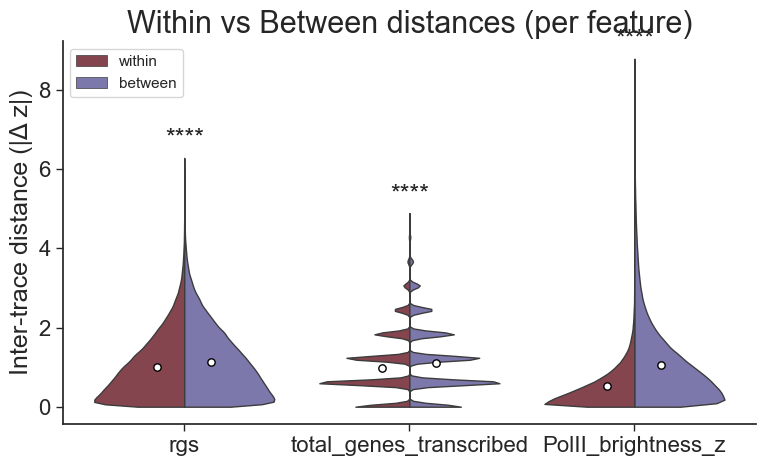

In [36]:
fig, ax = plot_split_violin_within_between(
    T[T['feature'].isin(main_features)],
    main_features,
    stats_df[stats_df['feature'].isin(main_features)],
    figsize = (8,5),
    palette=["#8E3B46", "#7570B3"], 
    add_strip=False,
    ylim=None,
    within_label="within",
    between_label="between",
    title="Within vs Between distances (per feature)",
    rasterize=False,
    ylabel = 'Inter-trace distance (|Δ z|)'
)

fig.savefig(
    "C:/GBM39/manuscript_figures/invitro_fig2/plots/within_vs_between/within_vs_between_split_violins_3_features_V2.svg",
    format="svg",
    transparent=True,
    dpi=300
)

plt.show()


## other antibody

In [24]:
antibody_features = ['SC35_brightness_z',
 'H3K27Ac_brightness_z',
 'Lamina_brightness_z',
 'NUP98_brightness_z']

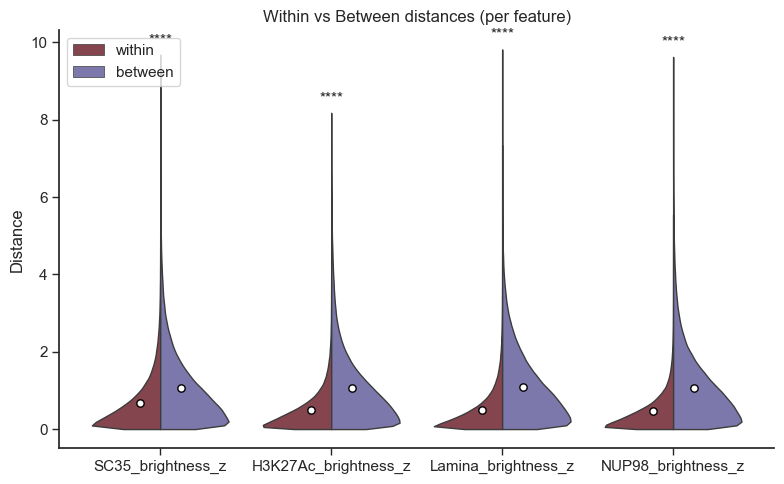

In [25]:
fig, ax = plot_split_violin_within_between(
    T[T['feature'].isin(antibody_features)],
    antibody_features,
    stats_df[stats_df['feature'].isin(antibody_features)],
    figsize = (8,5),
    palette=["#8E3B46", "#7570B3"], 
    add_strip=False,
    ylim=None,
    within_label="within",
    between_label="between",
    title="Within vs Between distances (per feature)",
    rasterize=False
)
plt.show()
